# Airport Baggage Delivery Time Analysis
### Exploratory Data Analysis & Probability Estimation

**Dataset:** Real-world airline baggage handling operations (~99K flights)  
**Target variable:** Baggage delivery time, minutes between flight arrival and last bag reaching baggage claim.

**Business question:** What does the distribution of delivery times look like, and what is the probability a flight delivers all bags within 21 minutes?

---


## Setup & Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import lognorm

# Consistent plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

---
## 1) Load Raw Data

We start by loading the raw CSV and taking stock of what we have before touching anything.


In [5]:
df_raw = pd.read_csv('Project_Data_2025.csv')

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print()
print(df_raw.dtypes)
print()
df_raw.head()


Shape: 99,174 rows × 7 columns

ActualArrival        object
FlightNumber          int64
Origin               object
Destination          object
ExpectedBagsCount     int64
FirstBagDropTime     object
LastBagDropTime      object
dtype: object



,ActualArrival,FlightNumber,Origin,Destination,ExpectedBagsCount,FirstBagDropTime,LastBagDropTime
0,7/22/21 8:20,8390,EVF,YZU,6,7/22/21 8:29,7/22/21 8:29
1,7/22/21 8:20,6898,CYT,YZU,24,7/22/21 8:30,7/22/21 8:31
2,7/22/21 8:20,3095,YZU,EVF,27,7/22/21 8:26,7/22/21 8:29
3,7/22/21 8:31,4821,CYT,YUX,17,7/22/21 8:41,7/22/21 8:45
4,7/22/21 8:33,2512,EYT,YZU,32,7/22/21 8:40,7/22/21 8:42


In [6]:
# Basic null check
print("Null counts per column:")
print(df_raw.isnull().sum())


Null counts per column:
ActualArrival        0
FlightNumber         0
Origin               0
Destination          0
ExpectedBagsCount    0
FirstBagDropTime     0
LastBagDropTime      0
dtype: int64


---
## 2) Data Quality Assessment

Before computing any statistics, we systematically flag every issue that could distort results.  
Each issue is counted so we understand both *what* is wrong and *how pervasive* it is.


In [8]:
df = df_raw.copy()

# Parse datetime columns
for col in ["ActualArrival", "FirstBagDropTime", "LastBagDropTime"]:
    df[col] = pd.to_datetime(df[col], format="mixed")

# Derive baggage delivery time (minutes)
df["BaggageDeliveryTime"] = (
    df["LastBagDropTime"] - df["ActualArrival"]
).dt.total_seconds() / 60

# Derived: unload duration and bag drop rate
df["UnloadDuration_min"] = (
    df["LastBagDropTime"] - df["FirstBagDropTime"]
).dt.total_seconds() / 60

df["BagsPerMinute"] = np.where(
    df["UnloadDuration_min"] > 0,
    df["ExpectedBagsCount"] / df["UnloadDuration_min"],
    np.nan
)

# Flag each issue
issues = {
    "Duplicate rows":                       df.duplicated().sum(),
    "Same origin & destination":            (df["Origin"] == df["Destination"]).sum(),
    "Zero expected bags (with drop times)": (df["ExpectedBagsCount"] == 0).sum(),
    "Zero or negative delivery time":       (df["BaggageDeliveryTime"] <= 0).sum(),
    "First == Last bag time (multi-bag)":   (
        (df["FirstBagDropTime"] == df["LastBagDropTime"]) &
        (df["ExpectedBagsCount"] > 1)
    ).sum(),
    "Bag drop rate > 45 bags/min":          (df["BagsPerMinute"] > 45).sum(),
}

issue_df = pd.DataFrame(
    {"Count": issues, "% of Raw Data": {k: v / len(df) * 100 for k, v in issues.items()}}
)
issue_df["% of Raw Data"] = issue_df["% of Raw Data"].map("{:.2f}%".format)
print(f"Raw dataset: {len(df):,} rows\n")
print(issue_df.to_string())


Raw dataset: 99,174 rows

                                      Count % of Raw Data
Duplicate rows                         8380         8.45%
Same origin & destination                35         0.04%
Zero expected bags (with drop times)     81         0.08%
Zero or negative delivery time          117         0.12%
First == Last bag time (multi-bag)     8885         8.96%
Bag drop rate > 45 bags/min            2514         2.53%


**Issue explanations:**

| Issue | Why it matters |
|---|---|
| **Duplicate rows** | Double-counts flights; inflates all statistical measures |
| **Same origin & destination** | Operationally impossible for commercial baggage handling; data entry error |
| **Zero expected bags with drop times** | If no bags are expected, no drop time should exist; system or entry error |
| **Zero/negative delivery time** | Bag logged before or exactly at arrival: physically impossible |
| **First == Last bag time (multi-bag)** | Multiple bags can't all be scanned at the same second; system limitation or entry error |
| **Bag drop rate > 45 bags/min** | Physically unrealistic throughput; flags implausible records |


---
## 3) Data Cleaning

We apply each fix sequentially and log the row count at every step.  
This makes the cleaning decisions transparent and reproducible.


In [9]:
cleaning_log = [("Raw data", len(df))]

# Step 1: Remove duplicates
df = df.drop_duplicates()
cleaning_log.append(("Remove duplicate rows", len(df)))

# Step 2: Remove same-airport flights
df = df[df["Origin"] != df["Destination"]]
cleaning_log.append(("Remove same origin/destination", len(df)))

# Step 3: Remove zero-bag flights
df = df[df["ExpectedBagsCount"] > 0]
cleaning_log.append(("Remove zero expected bags", len(df)))

# Step 4: Remove zero/negative delivery times
df = df[df["BaggageDeliveryTime"] > 0]
cleaning_log.append(("Remove zero/negative delivery time", len(df)))

# Step 5: Remove implausible bag timing (first == last, multi-bag)
df = df[~(
    (df["FirstBagDropTime"] == df["LastBagDropTime"]) &
    (df["ExpectedBagsCount"] > 1)
)]
cleaning_log.append(("Remove simultaneous first/last bag drop (multi-bag)", len(df)))

# Step 6: Z-score outlier removal on delivery time (±2.5 SD)
z_scores = np.abs(stats.zscore(df["BaggageDeliveryTime"]))
df = df[z_scores <= 2.5]
cleaning_log.append(("Remove Z-score outliers (±2.5 SD)", len(df)))

# Print cleaning log
log_df = pd.DataFrame(cleaning_log, columns=["Step", "Remaining Rows"])
log_df["Rows Removed"] = log_df["Remaining Rows"].shift(1).fillna(log_df["Remaining Rows"].iloc[0]).astype(int) - log_df["Remaining Rows"]
log_df.loc[0, "Rows Removed"] = 0
log_df["Rows Removed"] = log_df["Rows Removed"].astype(int)
log_df["% Retained"] = (log_df["Remaining Rows"] / log_df["Remaining Rows"].iloc[0] * 100).map("{:.1f}%".format)
print(log_df.to_string(index=False))

df_clean = df.reset_index(drop=True)
print(f"\nFinal clean dataset: {len(df_clean):,} rows")


                                               Step  Remaining Rows  Rows Removed % Retained
                                           Raw data           99174             0     100.0%
                              Remove duplicate rows           90794          8380      91.6%
                     Remove same origin/destination           90773            21      91.5%
                          Remove zero expected bags           90705            68      91.5%
                 Remove zero/negative delivery time           90601           104      91.4%
Remove simultaneous first/last bag drop (multi-bag)           82667          7934      83.4%
                  Remove Z-score outliers (±2.5 SD)           80922          1745      81.6%

Final clean dataset: 80,922 rows


---
## 4) Exploratory Data Analysis (EDA)

### 4.1 Descriptive Statistics


In [11]:
desc = df_clean["BaggageDeliveryTime"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
desc.index = ["Count", "Mean", "Std Dev", "Min", "5th Pct", "25th Pct",
              "Median", "75th Pct", "95th Pct", "Max"]
print("Baggage Delivery Time — Summary Statistics (minutes)\n")

for label, val in desc.items():
    if label == "Count":
        print(f"  {label:<15} {int(val):>10,}")
    else:
        print(f"  {label:<15} {val:>10.2f}")

skewness = df_clean["BaggageDeliveryTime"].skew()
kurtosis = df_clean["BaggageDeliveryTime"].kurtosis()
print(f"\n  {'Skewness':<15} {skewness:>10.3f}")
print(f"  {'Excess Kurtosis':<15} {kurtosis:>10.3f}")


Baggage Delivery Time — Summary Statistics (minutes)

  Count               80,922
  Mean                 15.51
  Std Dev               5.81
  Min                   1.00
  5th Pct               7.00
  25th Pct             11.00
  Median               15.00
  75th Pct             19.00
  95th Pct             26.00
  Max                  32.00

  Skewness             0.394
  Excess Kurtosis     -0.027


### 4.2 Distribution: Histogram & Box Plot

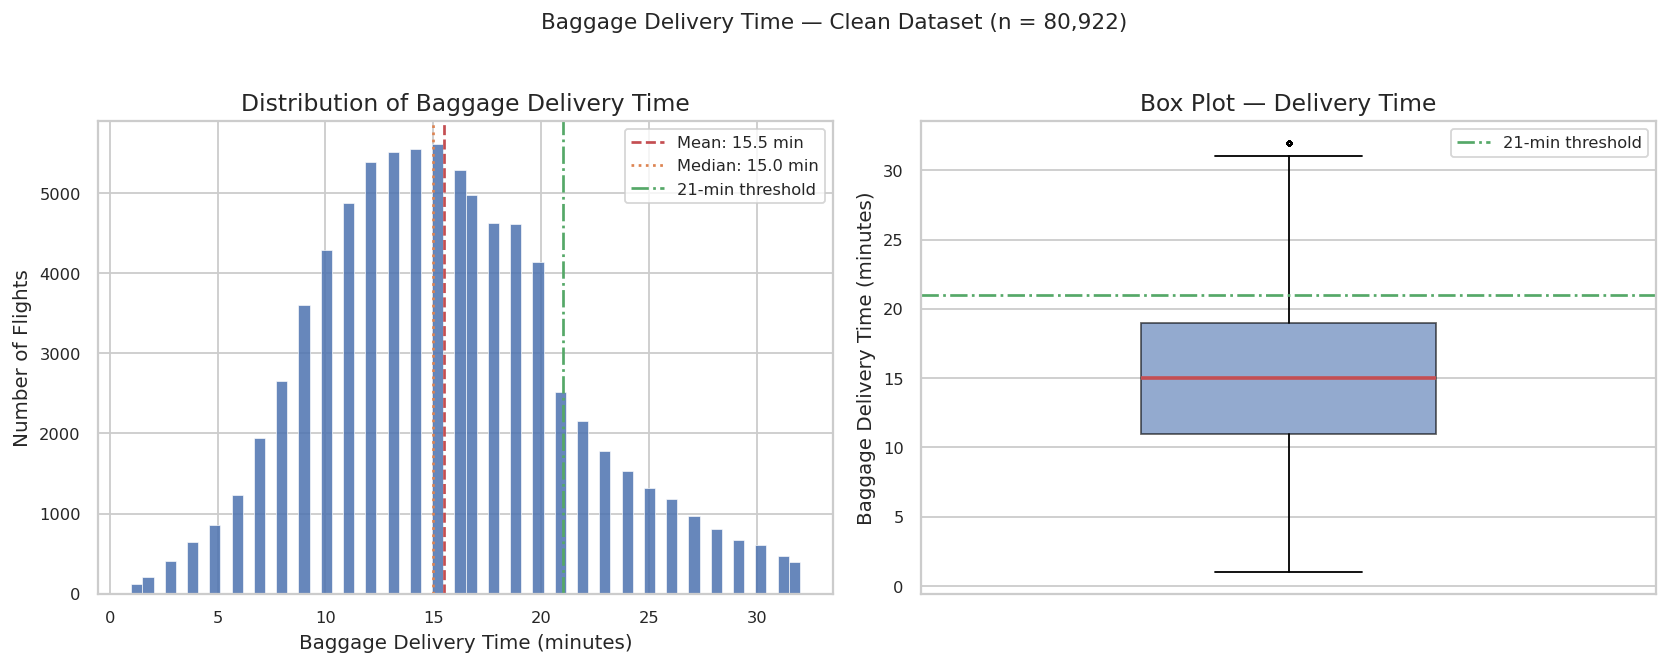

Right skew visible: mean > median — a small number of flights with long delivery times pull the mean upward.


In [14]:
import os

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
ax = axes[0]
ax.hist(df_clean["BaggageDeliveryTime"], bins=60, color="#4C72B0",
        edgecolor="white", linewidth=0.4, alpha=0.85)
ax.axvline(df_clean["BaggageDeliveryTime"].mean(), color="#C44E52",
           linestyle="--", linewidth=1.5, label=f'Mean: {df_clean["BaggageDeliveryTime"].mean():.1f} min')
ax.axvline(df_clean["BaggageDeliveryTime"].median(), color="#DD8452",
           linestyle=":", linewidth=1.5, label=f'Median: {df_clean["BaggageDeliveryTime"].median():.1f} min')
ax.axvline(21, color="#55A868", linestyle="-.", linewidth=1.5, label="21-min threshold")
ax.set_xlabel("Baggage Delivery Time (minutes)")
ax.set_ylabel("Number of Flights")
ax.set_title("Distribution of Baggage Delivery Time")
ax.legend(fontsize=9)

# Box Plot
ax2 = axes[1]
bp = ax2.boxplot(df_clean["BaggageDeliveryTime"], vert=True, patch_artist=True,
                 widths=0.4,
                 boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                 medianprops=dict(color="#C44E52", linewidth=2),
                 flierprops=dict(marker="o", markersize=2, alpha=0.3, color="#888"))
ax2.axhline(21, color="#55A868", linestyle="-.", linewidth=1.5, label="21-min threshold")
ax2.set_ylabel("Baggage Delivery Time (minutes)")
ax2.set_title("Box Plot — Delivery Time")
ax2.set_xticks([])
ax2.legend(fontsize=9)

plt.suptitle("Baggage Delivery Time — Clean Dataset (n = {:,})".format(len(df_clean)),
             fontsize=12, y=1.02)
plt.tight_layout()

# Create the output directory if doesn't exist
output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "fig_distribution.png"), bbox_inches="tight")
plt.show()
print("Right skew visible: mean > median — a small number of flights with long delivery times pull the mean upward.")

### 4.3 Before vs. After Cleaning: Distribution Shift

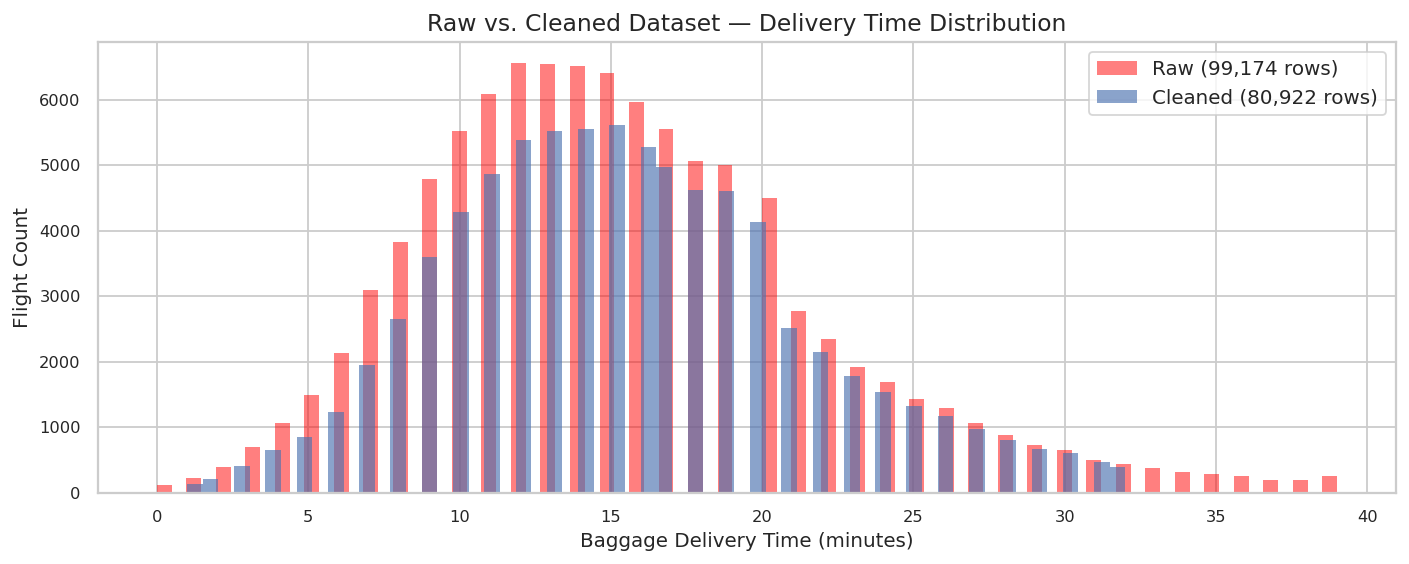

In [22]:
# Compute delivery time on full raw parsed data for comparison
df_before = df_raw.copy()
for col in ["ActualArrival", "FirstBagDropTime", "LastBagDropTime"]:
    df_before[col] = pd.to_datetime(df_before[col], format="mixed")
df_before["BaggageDeliveryTime"] = (
    df_before["LastBagDropTime"] - df_before["ActualArrival"]
).dt.total_seconds() / 60
df_before = df_before[df_before["BaggageDeliveryTime"].notna()]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(df_before["BaggageDeliveryTime"].clip(-5, 50), bins=80,
        alpha=0.5, color="red", label=f"Raw ({len(df_before):,} rows)", edgecolor="none")
ax.hist(df_clean["BaggageDeliveryTime"], bins=60,
        alpha=0.65, color="#4C72B0", label=f"Cleaned ({len(df_clean):,} rows)", edgecolor="none")
ax.set_xlabel("Baggage Delivery Time (minutes)")
ax.set_ylabel("Flight Count")
ax.set_title("Raw vs. Cleaned Dataset — Delivery Time Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/fig_before_after.png", bbox_inches="tight")
plt.show()
#C44E52 -- Red
#4C72B0 -- light Blue

### 4.4 Delivery Time by Hour of Day

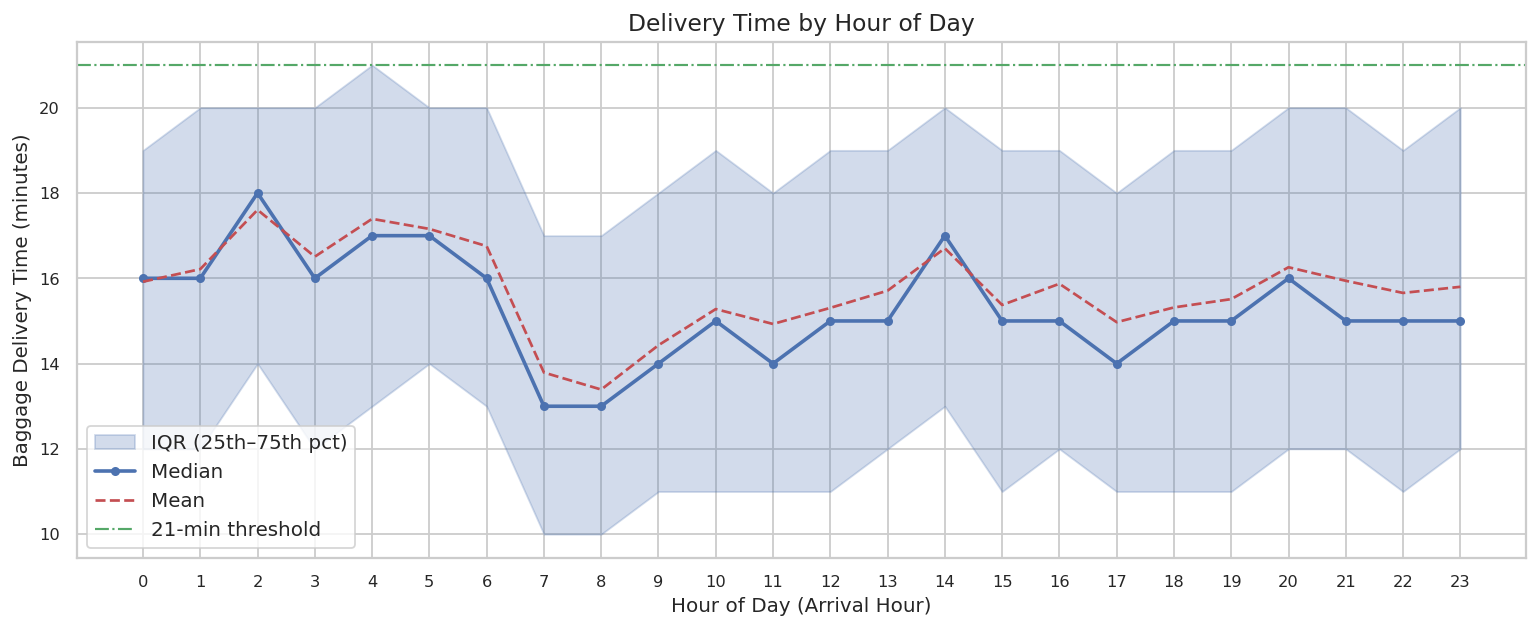

In [23]:
df_clean["ArrivalHour"] = df_clean["ActualArrival"].dt.hour

hourly = df_clean.groupby("ArrivalHour")["BaggageDeliveryTime"].agg(
    median="median", mean="mean", q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75), count="count"
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(hourly["ArrivalHour"], hourly["q25"], hourly["q75"],
                alpha=0.25, color="#4C72B0", label="IQR (25th–75th pct)")
ax.plot(hourly["ArrivalHour"], hourly["median"], color="#4C72B0",
        linewidth=2, marker="o", markersize=4, label="Median")
ax.plot(hourly["ArrivalHour"], hourly["mean"], color="#C44E52",
        linewidth=1.5, linestyle="--", label="Mean")
ax.axhline(21, color="#55A868", linestyle="-.", linewidth=1.2, label="21-min threshold")
ax.set_xlabel("Hour of Day (Arrival Hour)")
ax.set_ylabel("Baggage Delivery Time (minutes)")
ax.set_title("Delivery Time by Hour of Day")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/fig_hourly.png", bbox_inches="tight")
plt.show()


---
## 5) Probability Estimation: P(Delivery Time < 21 minutes)

We estimate this probability using two approaches: **empirical** (from observed data) and **theoretical** (via a fitted probability distribution).


### 5.1 Empirical Approach

In [27]:
threshold = 21
under_21 = (df_clean["BaggageDeliveryTime"] < threshold).sum()
p_empirical = under_21 / len(df_clean)

print(f"Flights with delivery time < {threshold} min: {under_21:,}")
print(f"Total flights (clean):       {len(df_clean):,}")
print(f"Empirical P(< {threshold} min):       {p_empirical:.4f}  →  {p_empirical*100:.1f}%")


Flights with delivery time < 21 min: 66,541
Total flights (clean):       80,922
Empirical P(< 21 min):       0.8223  →  82.2%


**Interpretation:** This is a direct frequency estimate from the data, no distributional assumptions required. It tells us exactly what happened in this dataset.


### 5.2 Theoretical Approach: Log-Normal Distribution

In [29]:
# Log-normal fit: fit on the log-transformed delivery times
log_times = np.log(df_clean["BaggageDeliveryTime"])
mu_log = log_times.mean()
sigma_log = log_times.std()

print(f"Log-normal parameters:")
print(f"  μ (log-scale mean):   {mu_log:.4f}")
print(f"  σ (log-scale std):    {sigma_log:.4f}")

# P(X < 21) using the fitted log-normal CDF
p_theoretical = lognorm.cdf(threshold, s=sigma_log, scale=np.exp(mu_log))
print(f"\nTheoretical P(< {threshold} min):  {p_theoretical:.4f}  →  {p_theoretical*100:.1f}%")
print(f"Difference vs. empirical: {abs(p_empirical - p_theoretical)*100:.2f} percentage points")


Log-normal parameters:
  μ (log-scale mean):   2.6607
  σ (log-scale std):    0.4313

Theoretical P(< 21 min):  0.8132  →  81.3%
Difference vs. empirical: 0.91 percentage points


### 5.3 Justification for Log-Normal Distribution

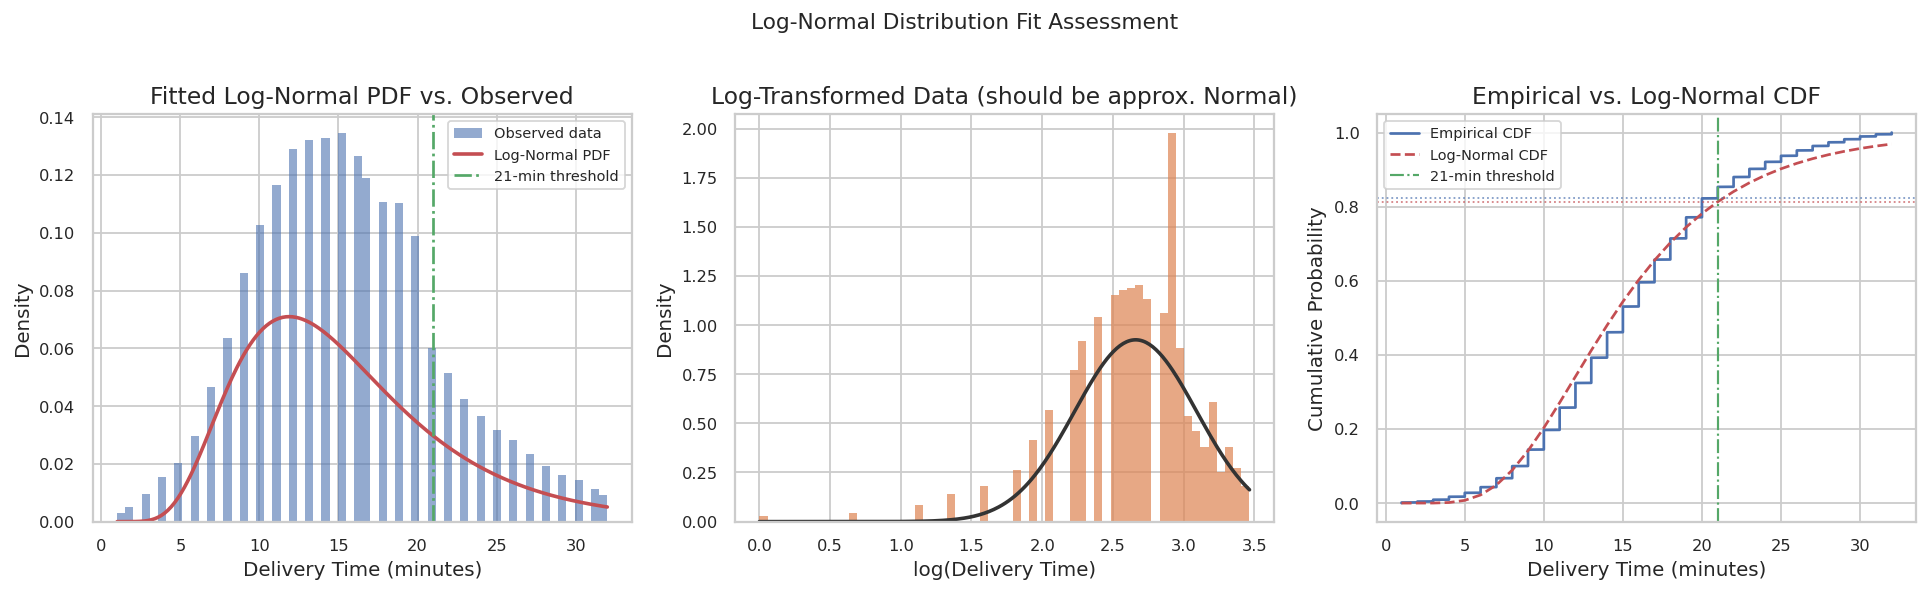

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Histogram + fitted PDF
ax = axes[0]
x_range = np.linspace(df_clean["BaggageDeliveryTime"].min(),
                       df_clean["BaggageDeliveryTime"].max(), 300)
pdf_fitted = lognorm.pdf(x_range, s=sigma_log, scale=np.exp(mu_log))

ax.hist(df_clean["BaggageDeliveryTime"], bins=60, density=True,
        color="#4C72B0", alpha=0.6, edgecolor="none", label="Observed data")
ax.plot(x_range, pdf_fitted, color="#C44E52", linewidth=2, label="Log-Normal PDF")
ax.axvline(21, color="#55A868", linestyle="-.", linewidth=1.5, label="21-min threshold")
ax.set_xlabel("Delivery Time (minutes)")
ax.set_ylabel("Density")
ax.set_title("Fitted Log-Normal PDF vs. Observed")
ax.legend(fontsize=8)

# Log-transformed distribution (should look normal)
ax2 = axes[1]
ax2.hist(log_times, bins=60, color="#DD8452", alpha=0.7, edgecolor="none", density=True)
x_log = np.linspace(log_times.min(), log_times.max(), 300)
from scipy.stats import norm as sp_norm
ax2.plot(x_log, sp_norm.pdf(x_log, mu_log, sigma_log), color="#333", linewidth=2)
ax2.set_xlabel("log(Delivery Time)")
ax2.set_ylabel("Density")
ax2.set_title("Log-Transformed Data (should be approx. Normal)")

# CDF comparison
ax3 = axes[2]
sorted_vals = np.sort(df_clean["BaggageDeliveryTime"])
ecdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
cdf_fitted = lognorm.cdf(sorted_vals, s=sigma_log, scale=np.exp(mu_log))

ax3.plot(sorted_vals, ecdf, color="#4C72B0", linewidth=1.5, label="Empirical CDF")
ax3.plot(sorted_vals, cdf_fitted, color="#C44E52", linewidth=1.5,
         linestyle="--", label="Log-Normal CDF")
ax3.axvline(21, color="#55A868", linestyle="-.", linewidth=1.2, label="21-min threshold")
ax3.axhline(p_empirical, color="#4C72B0", linestyle=":", linewidth=1, alpha=0.7)
ax3.axhline(p_theoretical, color="#C44E52", linestyle=":", linewidth=1, alpha=0.7)
ax3.set_xlabel("Delivery Time (minutes)")
ax3.set_ylabel("Cumulative Probability")
ax3.set_title("Empirical vs. Log-Normal CDF")
ax3.legend(fontsize=8)

plt.suptitle("Log-Normal Distribution Fit Assessment", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/fig_lognormal_fit.png", bbox_inches="tight")
plt.show()


### 5.4 Results Summary

In [35]:

print("  Prob Estimation Results\n")

print(f"  P(Delivery Time < 21 min)")
print(f"  {'Empirical':30s} {p_empirical*100:.1f}%")
print(f"  {'Theoretical (Log-Normal)':30s} {p_theoretical*100:.1f}%")
print(f"  {'Difference':30s} {abs(p_empirical - p_theoretical)*100:.2f} pp")
print()
print("  Why Log-Normal?")
print("  - Delivery time is strictly positive (log-normal is bounded at 0)")
print("  - Right-skewed distribution — matches log-normal shape")
print("  - Log-transformed values are approximately normally distributed")
print("  - CDF tracks closely with the empirical CDF across the full range")


  Prob Estimation Results

  P(Delivery Time < 21 min)
  Empirical                      82.2%
  Theoretical (Log-Normal)       81.3%
  Difference                     0.91 pp

  Why Log-Normal?
  - Delivery time is strictly positive (log-normal is bounded at 0)
  - Right-skewed distribution — matches log-normal shape
  - Log-transformed values are approximately normally distributed
  - CDF tracks closely with the empirical CDF across the full range


---
## 6) Key Findings & Business Implications

| Finding | Detail |
|---|---|
| **Average delivery time** | ~15.5 minutes after landing |
| **Typical range (IQR)** | 11 to 19 minutes |
| **Distribution shape** | Right-skewed — fast for most flights, with a tail of slower deliveries |
| **P(< 21 minutes)** | ~82% empirical / ~80% theoretical |
| **Data quality impact** | 18,252 rows (~18.4%) removed before analysis was valid |

**Operational implications:**
- A 21-minute SLA would be met roughly 80–82% of the time under current operations
- The right skew means there is a meaningful tail of flights exceeding 25+ minutes — these are candidates for root cause analysis
- Hour-of-day patterns (see Section 4.4) could inform staffing decisions to address peak-period delays


---
## 7) Methodology Notes

**Cleaning order matters:** Steps were applied sequentially. Removing duplicates first ensures Z-score outlier detection isn't influenced by repeated observations. The Z-score threshold of ±2.5 SD retains ~98.75% of data; less aggressive than ±2.0 (95.5%) but tighter than ±3.0 (99.7%).

**Empirical vs. theoretical tradeoff:**
- The empirical approach is exact for this dataset but cannot generalize to future flights or answer "what if we see a new airport?"
- The log-normal model provides a generative framework, useful for simulation, scheduling optimization, or SLA setting, but depends on the distributional assumption holding
- The ~2-percentage-point gap between methods suggests the log-normal is a reasonable but imperfect fit; the right tail is slightly heavier in practice than the model predicts

**Tools used:** Python 3 · pandas · NumPy · SciPy · Matplotlib · Seaborn
